# CAFA evaluation

Scores trained deepFRI2 runs against deepFRI v1 and the published competitors, on the three
splits (evaluation, test, CAZy) and the three ontologies (MF, CC, BP), and draws the figures
and tables for the paper.

Scores come from [CAFA-evaluator](https://github.com/BioComputingUP/CAFA-evaluator)
(`pip install cafaeval`) and are cached next to the predictions, so a method that has already
been scored is loaded rather than recomputed -- the notebook then runs end to end in seconds
and does not even need `cafaeval` installed. A run that has never been scored is scored on the
spot; `recompute=True` below redoes the ones that have.

Everything lands in one table, `curves` -- one row per `(method, ontology, split, tau)`,
holding both the unweighted and the information-accretion weighted metrics -- from which every
figure and table here is a groupby. `weighted=` picks a weighting at read time, so switching a
figure or a table between the two never re-runs anything.

The machinery is in [`utils/evaluator.py`](src/deepfri2_trainer/utils/evaluator.py) and
[`utils/figures.py`](src/deepfri2_trainer/utils/figures.py); everything specific to this
machine, this dataset and this set of competitors is in the **Setup** cell below.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd() / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from deepfri2_trainer.utils import figures
from deepfri2_trainer.utils.evaluator import CafaEvaluation, EvalPaths

pd.set_option("display.width", 160)

## Setup

Everything user-specific lives here: which runs to score, and how methods are named and
coloured. Paths, dataset versions and `runs_dir` all come from `configs/paths.yaml` and
`configs/data.yaml`, so the evaluation follows the data the models were trained on; pass
`EvalPaths.from_configs(data_version="<DATE>")` to override any of it.


### Paths

In [ ]:
# Every data path lives in the `layout:` block of configs/paths.yaml -- the same block
# `RunConfig` resolves training paths from, so the evaluation cannot drift from the data the
# models were trained on. Point somewhere else by editing that file, not this cell.
paths = EvalPaths.from_configs()
FIGURE_DIR = Path("figures")

print(paths.project_location, paths.dataset_name, sep="\n")
for key in sorted(paths.layout):
    print(f"  {key:<18} {paths.layout[key]}")

### Models to be validated

In [3]:
RUNS = {
    "MF": {
        "deepFRI2 (sequence)": "comfy-silence-824",
        "deepFRI2 (structure)": "good-glitter-814",
        "deepFRI2 (fusion)": "dainty-deluge-829",
        # "deepFRI2 (sequence, train+eval)": "deft-field-839",
        # "deepFRI2 (kernel, train+eval)": "warm-yogurt-840",
        # "deepFRI2 (fusion, train+eval)": "devoted-planet-841",
    },
    "CC": {
        "deepFRI2 (sequence)": "valiant-waterfall-833",
        "deepFRI2 (structure)": "daily-firefly-834",
        "deepFRI2 (fusion)": "divine-donkey-835",
        # "deepFRI2 (sequence, train+eval)": "stilted-sun-842",
        # "deepFRI2 (structure, train+eval)": "gentle-plasma-843",
        # "deepFRI2 (fusion, train+eval)": "sweet-capybara-844",
    },
    "BP": {
        "deepFRI2 (sequence)": "autumn-shape-836",
        "deepFRI2 (structure)": "comic-cloud-837",
        "deepFRI2 (fusion)": "leafy-silence-838",
        # "deepFRI2 (sequence, train+eval)": "graceful-feather-845",
        # "deepFRI2 (structure, train+eval)": "clear-sponge-846",
        # "deepFRI2 (fusion, train+eval)": "magic-resonance-847",
    },
}

DEEPFRI1 = "deepFRI"

# Competitor predictions are named after the authors' repositories, which is not always what the
# method is called: `deepgo2` is the repository of DeepGO-SE
COMPETITORS = {
    "funfams_go_preds.tsv": "FunFams",
    "deepgo2_go_preds.tsv": "DeepGO-SE",
    "deepgometa_go_preds.tsv": "DeepGO-meta",
    "emapper_go_preds.tsv": "eggNOG-mapper",
    "po2go_go_preds.tsv": "PO2GO",
}

# Methods to be included. Set KEEP = None to show every one
KEEP = ["FunFams", "DeepGO-SE", "eggNOG-mapper", "PO2GO"]

### Labels and colors

In [4]:
# Naming and colours used by every figure. A method keeps its colour across the whole paper.
# deepFRI2's own models are not listed: they are coloured by sub-model via figures.MODEL_COLORS
# -- violet for sequence, blue for structure, red for fusion. Competitors below avoid those hues.
figures.SPLIT_LABELS = {
    "eval": "Evaluation set",  # HOMO-50
    "test": "Test set",        # TEMP-23
    "cazy": "CAZy test set",   # CAZy
}
figures.PALETTE = {
    DEEPFRI1: "#ff7f0e",
    "FunFams": "#8c564b",
    "DeepGO-SE": "#2ca02c",
    "DeepGO-meta": "#7f7f7f",
    "eggNOG-mapper": "#bcbd22",
    "PO2GO": "#e377c2",
}
figures.STYLE["figsize"] = (5.5, 4.4)   # per panel; see figures.STYLE for the rest

## Score

Each `add_*` call loads cached scores, or computes and caches them if they are missing. Restrict
the work with `ontologies=` / `splits=`; pass `recompute=True` to score everything again (needed
after changing a CAFA-evaluator parameter).

In [5]:
ev = CafaEvaluation(paths)  # CafaEvaluation(paths, recompute=True, splits=("test",), ...)
ev.add_runs(RUNS)
ev.add_deepfri1(DEEPFRI1)
ev.add_competitors(COMPETITORS, keep=KEEP)

curves = ev.curves
print(curves.shape)
curves.head()

loading deepFRI2 (sequence) [MF/eval]
loading deepFRI2 (sequence) [MF/test]
loading deepFRI2 (sequence) [MF/cazy]
loading deepFRI2 (structure) [MF/eval]
loading deepFRI2 (structure) [MF/test]
loading deepFRI2 (structure) [MF/cazy]
loading deepFRI2 (fusion) [MF/eval]
loading deepFRI2 (fusion) [MF/test]
loading deepFRI2 (fusion) [MF/cazy]
loading deepFRI2 (sequence) [CC/eval]
loading deepFRI2 (sequence) [CC/test]
loading deepFRI2 (sequence) [CC/cazy]
loading deepFRI2 (structure) [CC/eval]
loading deepFRI2 (structure) [CC/test]
loading deepFRI2 (structure) [CC/cazy]
loading deepFRI2 (fusion) [CC/eval]
loading deepFRI2 (fusion) [CC/test]
loading deepFRI2 (fusion) [CC/cazy]
loading deepFRI2 (sequence) [BP/eval]
loading deepFRI2 (sequence) [BP/test]
loading deepFRI2 (sequence) [BP/cazy]
loading deepFRI2 (structure) [BP/eval]
loading deepFRI2 (structure) [BP/test]
loading deepFRI2 (structure) [BP/cazy]
loading deepFRI2 (fusion) [BP/eval]
loading deepFRI2 (fusion) [BP/test]
loading deepFRI2 (f

,method,ontology,split,tau,n,tp,fp,fn,pr,rc,...,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w
0,deepFRI2 (sequence),MF,eval,0.01,7518.0,7.105879,33.346635,1.384810,0.201021,0.879057,...,0.128430,0.824641,1.0,105.178883,4.739904,0.222248,105.285631,0.105330,0.723180,0.183879
1,deepFRI2 (sequence),MF,eval,0.02,7518.0,6.846103,20.739425,1.644586,0.278720,0.857139,...,0.184208,0.792559,1.0,63.878127,5.546206,0.298937,64.118449,0.153423,0.676091,0.250094
2,deepFRI2 (sequence),MF,eval,0.03,7518.0,6.660415,15.360867,1.830274,0.337157,0.841895,...,0.228312,0.770741,1.0,46.032674,6.104008,0.352273,46.435611,0.193137,0.643514,0.297104
3,deepFRI2 (sequence),MF,eval,0.04,7518.0,6.524475,12.328811,1.966214,0.385065,0.829942,...,0.267441,0.751388,1.0,35.956795,6.540763,0.394476,36.546857,0.227379,0.618007,0.332444
4,deepFRI2 (sequence),MF,eval,0.05,7518.0,6.410748,10.368981,2.079941,0.425139,0.820365,...,0.302281,0.735172,1.0,29.406095,6.930978,0.428412,30.211867,0.257381,0.595217,0.359367


## Tables

`summary()` reads each method's optimum off its curve: `fmax` (with the threshold and the
precision, recall and coverage there), `f_micro` and `smin`. `table()` pivots one of those to
methods x ontologies for one split.

Both take `weighted=`, and both carry the title and file name they should be saved under -- so
`figures.save(table, FIGURE_DIR)` cannot file a CAZy table as a test one.

In [6]:
summary = ev.summary(weighted=True)
summary

,method,ontology,split,fmax,tau,precision,recall,coverage,f_micro,smin
0,deepFRI2 (sequence),MF,eval,0.632,0.35,0.737,0.553,0.998,0.476,11.339
1,deepFRI2 (sequence),MF,test,0.709,0.37,0.753,0.669,0.997,0.589,8.580
2,deepFRI2 (sequence),MF,cazy,0.701,0.18,0.709,0.692,1.000,0.720,6.994
3,deepFRI2 (structure),MF,eval,0.547,0.47,0.673,0.461,0.999,0.377,13.030
4,deepFRI2 (structure),MF,test,0.622,0.49,0.722,0.547,0.997,0.492,10.243
...,...,...,...,...,...,...,...,...,...,...
67,DeepGO-SE,BP,test,0.307,0.29,0.285,0.332,0.999,0.270,35.121
68,FunFams,BP,cazy,0.099,0.01,0.579,0.054,0.070,0.086,19.769
69,eggNOG-mapper,BP,cazy,0.153,0.01,0.452,0.092,0.143,0.138,19.152
70,PO2GO,BP,cazy,0.506,0.01,0.529,0.485,0.908,0.469,17.938


In [7]:
summary[summary['ontology']=='MF']

,method,ontology,split,fmax,tau,precision,recall,coverage,f_micro,smin
0,deepFRI2 (sequence),MF,eval,0.632,0.35,0.737,0.553,0.998,0.476,11.339
1,deepFRI2 (sequence),MF,test,0.709,0.37,0.753,0.669,0.997,0.589,8.580
2,deepFRI2 (sequence),MF,cazy,0.701,0.18,0.709,0.692,1.000,0.720,6.994
3,deepFRI2 (structure),MF,eval,0.547,0.47,0.673,0.461,0.999,0.377,13.030
4,deepFRI2 (structure),MF,test,0.622,0.49,0.722,0.547,0.997,0.492,10.243
5,deepFRI2 (structure),MF,cazy,0.340,0.39,0.420,0.285,1.000,0.267,15.668
6,deepFRI2 (fusion),MF,eval,0.633,0.32,0.721,0.564,0.999,0.479,11.312
7,deepFRI2 (fusion),MF,test,0.709,0.40,0.769,0.658,0.997,0.589,8.594
8,deepFRI2 (fusion),MF,cazy,0.703,0.18,0.716,0.691,1.000,0.725,6.910
27,deepFRI,MF,eval,0.344,0.19,0.323,0.368,0.806,0.307,14.493


In [8]:
ev.table("fmax", split="test", weighted=True)

ontology,MF,CC,BP
method,,,
deepFRI2 (sequence),0.709,0.586,0.352
deepFRI2 (structure),0.622,0.472,0.288
deepFRI2 (fusion),0.709,0.586,0.359
deepFRI,0.371,0.413,0.207
FunFams,0.452,0.443,0.288
eggNOG-mapper,0.496,0.540,0.263
PO2GO,0.539,0.575,0.291
DeepGO-SE,0.609,0.522,0.307


In [9]:
# for weighted in (True, False):
#     for split in ("eval", "test", "cazy"):
#         table = ev.table("fmax", split=split, weighted=weighted)
#         print(f"\n=== {table.attrs['title']} ===")
#         print(table)
#         figures.save(table, FIGURE_DIR)   # -> table_fmax_<split>_<weighting>.csv / .tex

## Figures

Two primitives -- `figures.curve` (a metric against the threshold) and `figures.pr_curve`
(precision against recall) -- draw into an axes; `panel`, `compare` and `bars` arrange them.
All of them take `weighted=`.

Each figure titles itself from what it plots and carries the matching file name, so `save` takes
a **directory**, never a name.

[PosixPath('figures/panel_test_MF_weighted.png'),
 PosixPath('figures/panel_test_MF_weighted.pdf')]

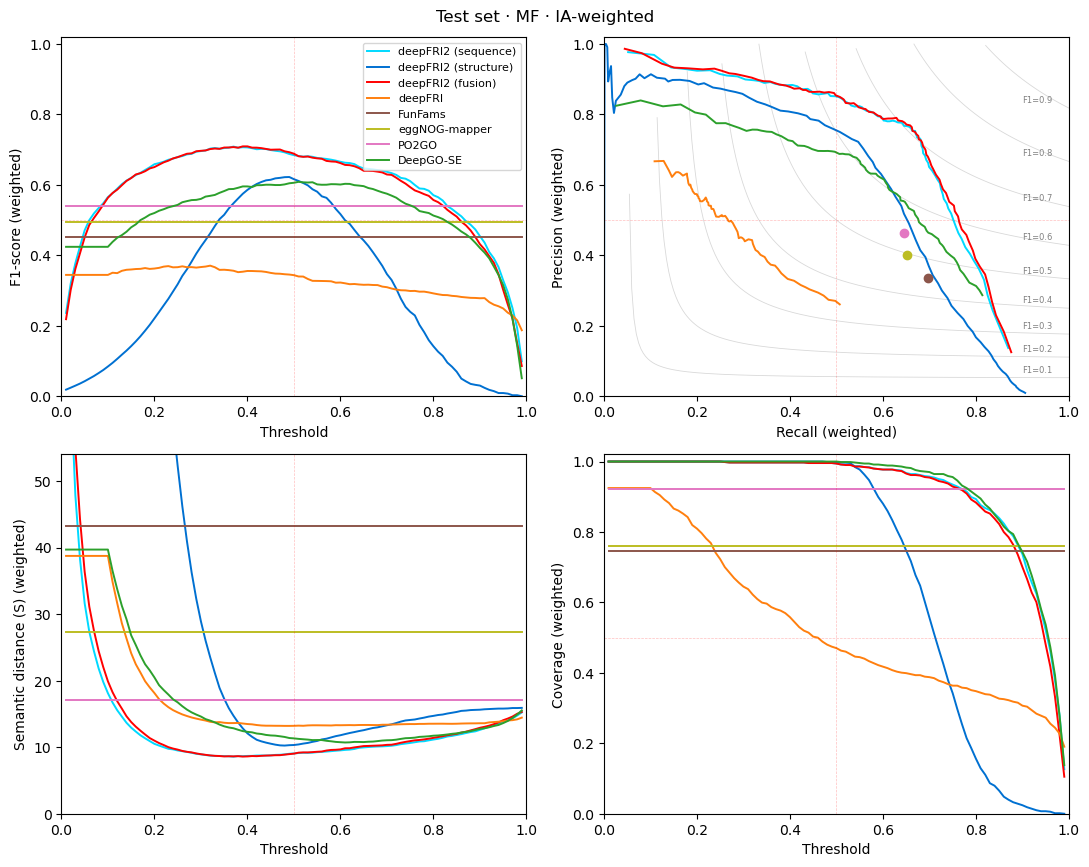

In [10]:
fig, axes = figures.panel(curves, split="test", ontology="MF", weighted=True)
figures.save(fig, FIGURE_DIR)   # -> panel_test_MF_weighted.png / .pdf

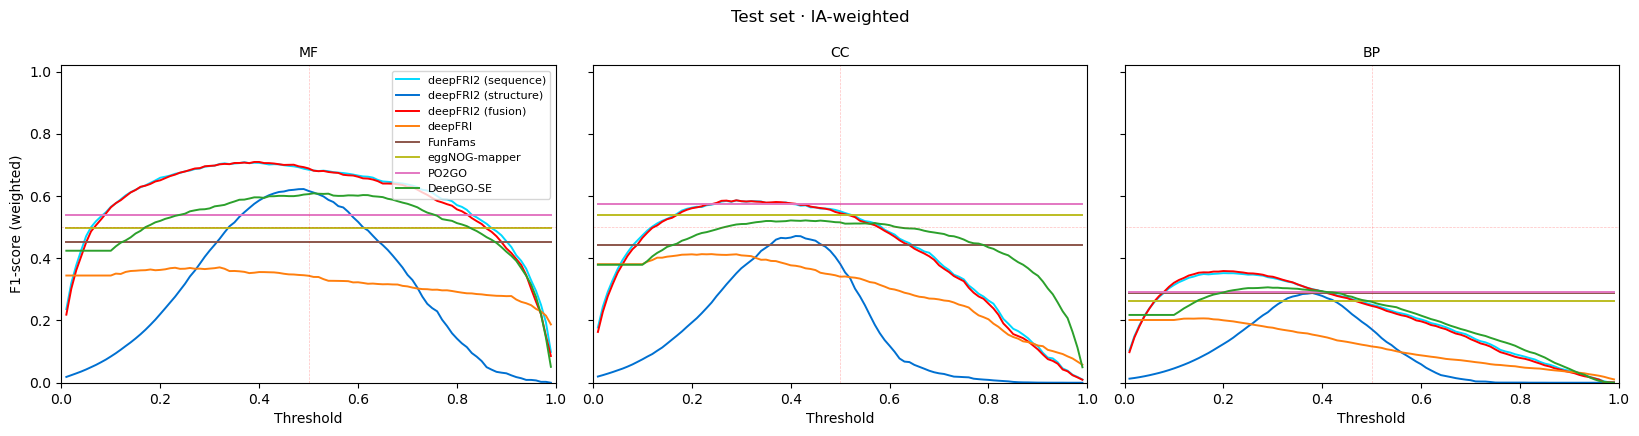

In [11]:
# F1 curves across the three ontologies
fig, axes = figures.compare(curves, "f", by="ontology", split="test", weighted=True)
figures.save(fig, FIGURE_DIR);

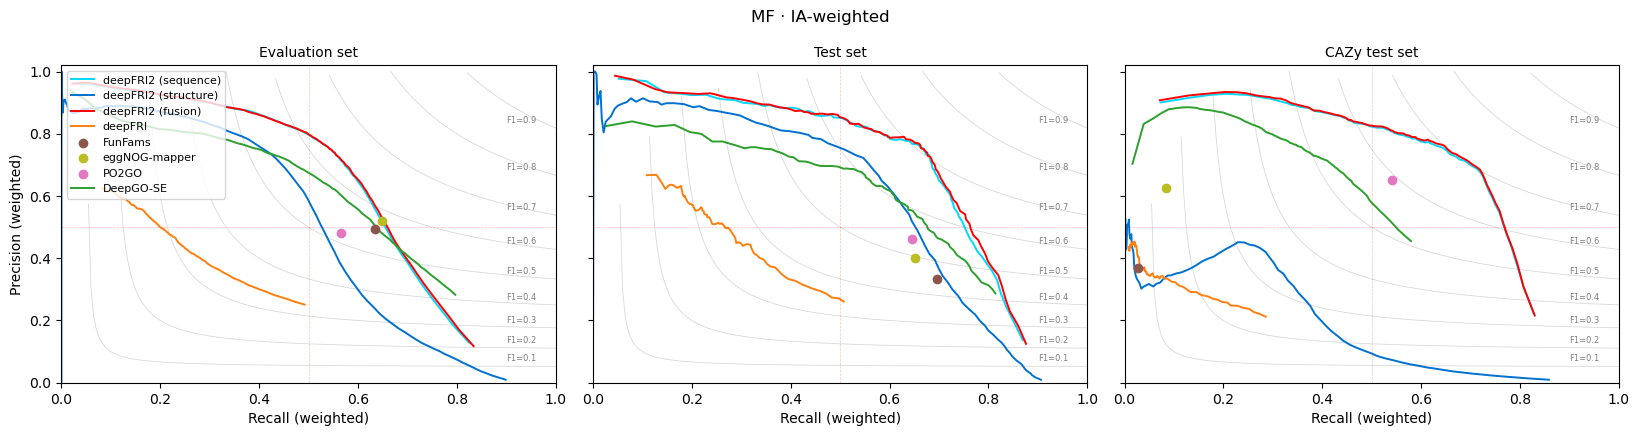

In [12]:
# The same model across the three splits
fig, axes = figures.compare(curves, "pr_rc", by="split", ontology="MF", weighted=True)
figures.save(fig, FIGURE_DIR);

[PosixPath('figures/bars_fmax_test_weighted.png'),
 PosixPath('figures/bars_fmax_test_weighted.pdf')]

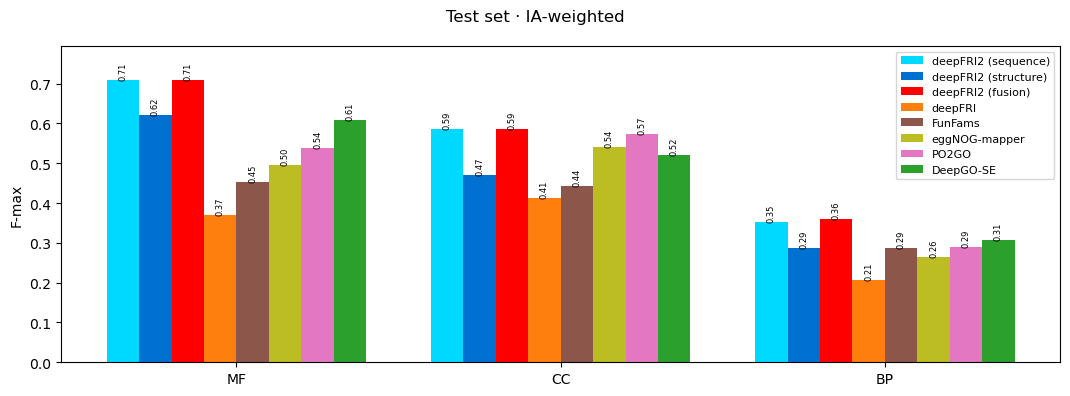

In [13]:
fig, ax = figures.bars(curves, "fmax", split="test", weighted=True)
figures.save(fig, FIGURE_DIR)   # -> bars_fmax_cazy_weighted.png / .pdf

In [14]:
# Every panel of the paper, both weightings, correctly named
for weighted in (True, False):
    for split in ("eval", "test", "cazy"):
        for ontology in ("MF", "CC", "BP"):
            fig, _ = figures.panel(curves, split=split, ontology=ontology, weighted=weighted)
            figures.save(fig, FIGURE_DIR)
            plt.close(fig)

sorted(p.name for p in FIGURE_DIR.glob("panel_*.png"))

['panel_cazy_BP_unweighted.png',
 'panel_cazy_BP_weighted.png',
 'panel_cazy_CC_unweighted.png',
 'panel_cazy_CC_weighted.png',
 'panel_cazy_MF_unweighted.png',
 'panel_cazy_MF_weighted.png',
 'panel_eval_BP_unweighted.png',
 'panel_eval_BP_weighted.png',
 'panel_eval_CC_unweighted.png',
 'panel_eval_CC_weighted.png',
 'panel_eval_MF_unweighted.png',
 'panel_eval_MF_weighted.png',
 'panel_test_BP_unweighted.png',
 'panel_test_BP_weighted.png',
 'panel_test_CC_unweighted.png',
 'panel_test_CC_weighted.png',
 'panel_test_MF_unweighted.png',
 'panel_test_MF_weighted.png']

### Customising

Every function takes `ax`, `methods` (which methods, in what order), `colors`, `labels` and
`emphasis` (drawn thicker; deepFRI2 variants by default), forwards anything else to matplotlib
and returns the axes -- so a figure that is nearly right can be finished by hand. A figure you
assemble yourself gets no automatic name, so give `save` one.

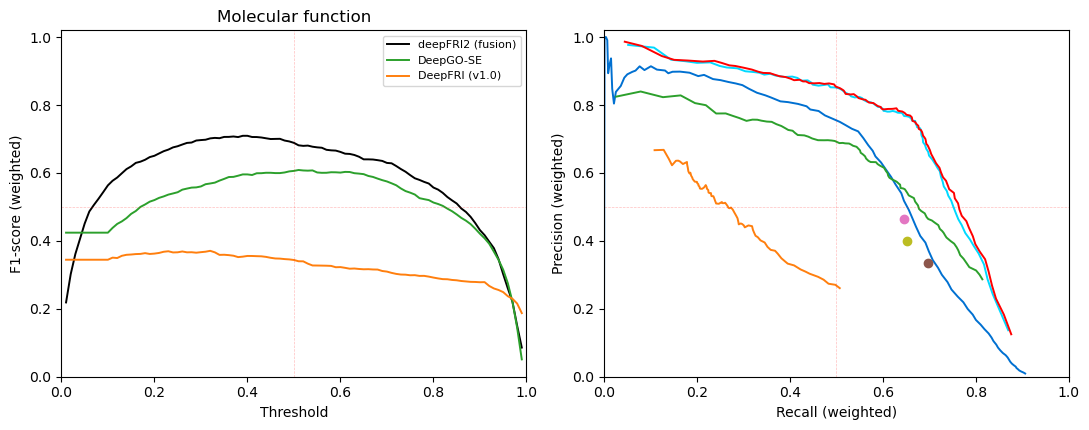

In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.4))

figures.curve(
    curves, "f",
    split="test", ontology="MF", weighted=True,
    methods=["deepFRI2 (fusion)", "DeepGO-SE", DEEPFRI1],  # subset, and the legend order
    colors={"deepFRI2 (fusion)": "k"},
    labels={DEEPFRI1: "DeepFRI (v1.0)"},
    ax=left,
)
figures.pr_curve(curves, split="test", ontology="MF", weighted=True,
                 iso_f1=False, legend=False, ax=right)

left.set_title("Molecular function")
fig.tight_layout()
figures.save(fig, FIGURE_DIR, name="fig3_MF");

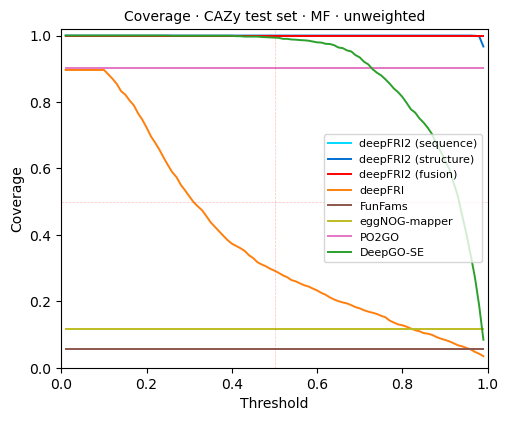

In [16]:
# Any CAFA-evaluator column, either weighting
figures.curve(curves, "cov", split="cazy", ontology="MF", weighted=False);

## Scoring a new run

Train a model, write its predictions (`write_all_predictions`, or a full `python train.py` run,
which does it at the end), then add it here by run name. The TSVs are looked up in the run
directory under `runs_dir` and in the shared predictions directory; the scores are cached next
to whichever was found.

In [17]:
# new = CafaEvaluation(paths, ontologies=("MF",), splits=("test", "cazy"))
# new.add_runs({"MF": {"deepFRI2 (new)": "my-wandb-run-name"}})
# new.add_competitors(COMPETITORS, keep=KEEP)
# new.summary()